<a href="https://www.kaggle.com/code/sonawanelalitsunil/grammy-awards-winner-predictor-ml-98-31?scriptVersionId=229050690" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/grammy-winners-and-nominees-from-1965-to-2024/grammy_winners.csv


## Title: Grammy Awards Winner Predictor

##### Description: This project analyzes past Grammy Awards data to predict future winners based on factors such as artist popularity, past nominations, streaming metrics, genre trends, and critical reception. Using machine learning models, it identifies patterns in award-winning characteristics and provides data-driven insights into potential winners.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/grammy-winners-and-nominees-from-1965-to-2024/grammy_winners.csv')

In [3]:
df.head()

,year,annual_edition,category,artist,song_or_album,winner,url
0,2024,67,Album Of The Year,"Jack Antonoff, Aaron Dessner & Taylor Swift, p...",THE TORTURED POETS DEPARTMENT,False,https://www.grammy.com/awards/67th-annual-gram...
1,2024,67,Album Of The Year,Beyoncé,COWBOY CARTER,True,https://www.grammy.com/awards/67th-annual-gram...
2,2024,67,Record Of The Year,"Giles Martin & Paul McCartney, producers; Geof...",Now And Then,False,https://www.grammy.com/awards/67th-annual-gram...
3,2024,67,Record Of The Year,"Beyoncé, Nate Ferraro, Killah B & Raphael Saad...",TEXAS HOLD 'EM,False,https://www.grammy.com/awards/67th-annual-gram...
4,2024,67,Record Of The Year,"Julian Bunetta, producer; Julian Bunetta & Jef...",Espresso,False,https://www.grammy.com/awards/67th-annual-gram...


In [4]:
df.tail()

,year,annual_edition,category,artist,song_or_album,winner,url
25364,1958,1,Album Of The Year,NaN,Only The Lonely (Album),False,https://www.grammy.com/awards/1st-annual-gramm...
25365,1958,1,Album Of The Year,NaN,Ella Fitzgerald Sings The Irving Berlin Song B...,False,https://www.grammy.com/awards/1st-annual-gramm...
25366,1958,1,"Best Vocal Performance, Male",Perry Como,Catch A Falling Star,True,https://www.grammy.com/awards/1st-annual-gramm...
25367,1958,1,"Best Vocal Performance, Male",NaN,Witchcraft (Single),False,https://www.grammy.com/awards/1st-annual-gramm...
25368,1958,1,"Best Vocal Performance, Male",NaN,Nel Blu Dipinto Di Blu (Volare) (Single),False,https://www.grammy.com/awards/1st-annual-gramm...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25369 entries, 0 to 25368
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   year            25369 non-null  int64 
 1   annual_edition  25369 non-null  int64 
 2   category        25369 non-null  object
 3   artist          13190 non-null  object
 4   song_or_album   25348 non-null  object
 5   winner          25369 non-null  bool  
 6   url             25369 non-null  object
dtypes: bool(1), int64(2), object(4)
memory usage: 1.2+ MB


In [6]:
df.describe()

,year,annual_edition
count,25369.000000,25369.000000
mean,1995.791360,38.791360
std,17.998934,17.998934
min,1958.000000,1.000000
25%,1982.000000,25.000000
50%,1998.000000,41.000000
75%,2010.000000,53.000000
max,2024.000000,67.000000


In [7]:
df.isnull().sum()

year                  0
annual_edition        0
category              0
artist            12179
song_or_album        21
winner                0
url                   0
dtype: int64

In [8]:
df.duplicated().sum()

17

In [9]:
df.shape

(25369, 7)

In [10]:
df.corr

<bound method DataFrame.corr of        year  annual_edition                      category  \
0      2024              67             Album Of The Year   
1      2024              67             Album Of The Year   
2      2024              67            Record Of The Year   
3      2024              67            Record Of The Year   
4      2024              67            Record Of The Year   
...     ...             ...                           ...   
25364  1958               1             Album Of The Year   
25365  1958               1             Album Of The Year   
25366  1958               1  Best Vocal Performance, Male   
25367  1958               1  Best Vocal Performance, Male   
25368  1958               1  Best Vocal Performance, Male   

                                                  artist  \
0      Jack Antonoff, Aaron Dessner & Taylor Swift, p...   
1                                                Beyoncé   
2      Giles Martin & Paul McCartney, producers; Geof..

In [11]:
df.columns

Index(['year', 'annual_edition', 'category', 'artist', 'song_or_album',
       'winner', 'url'],
      dtype='object')

## Data visualizations

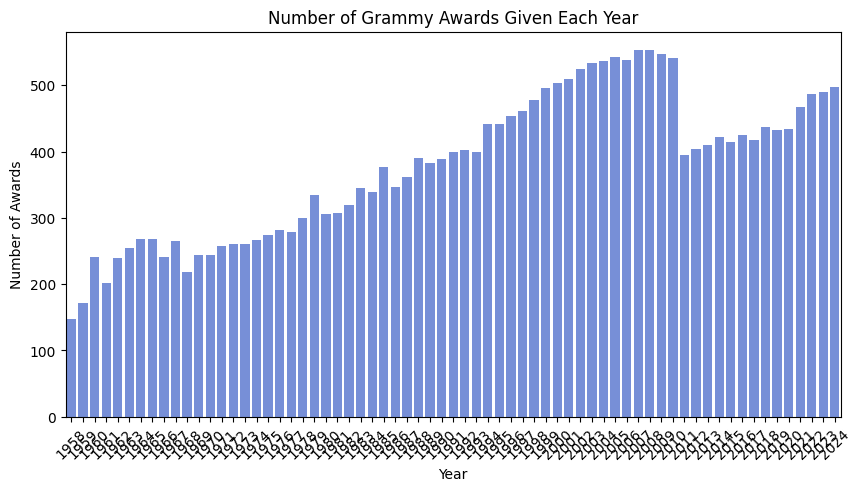

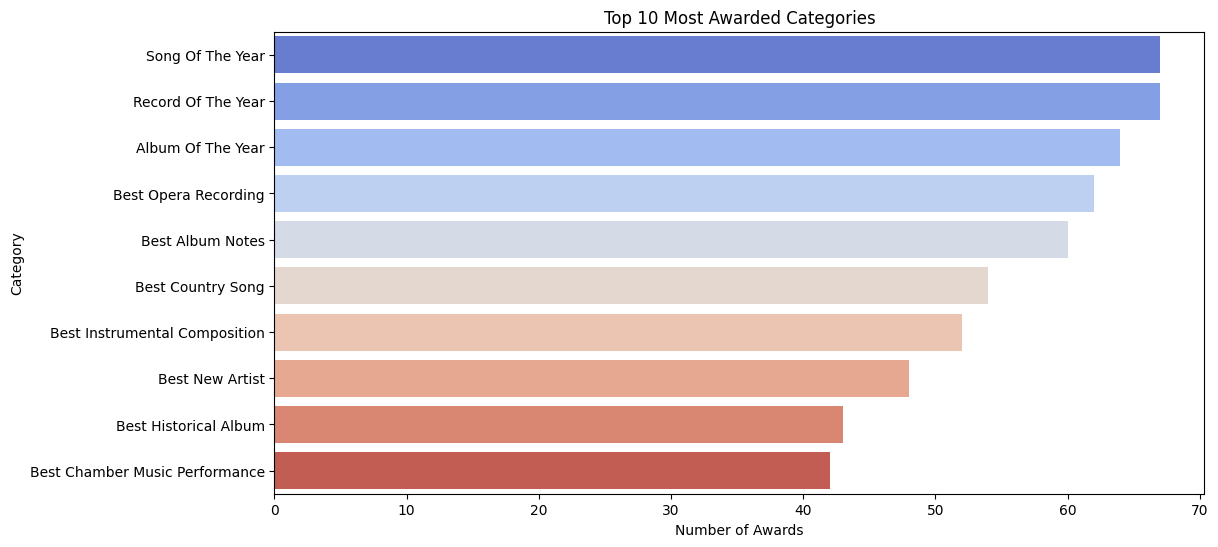

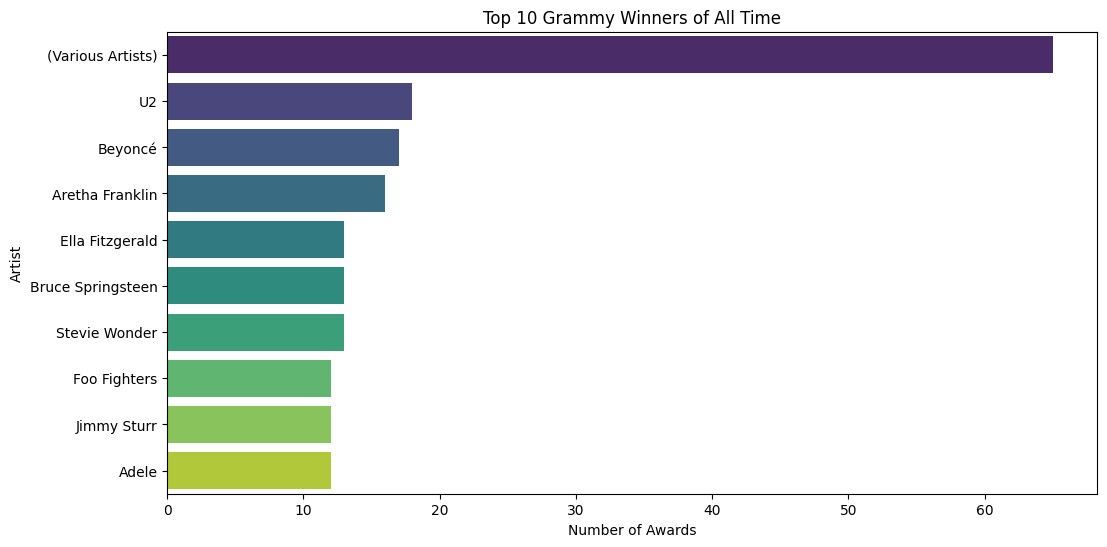

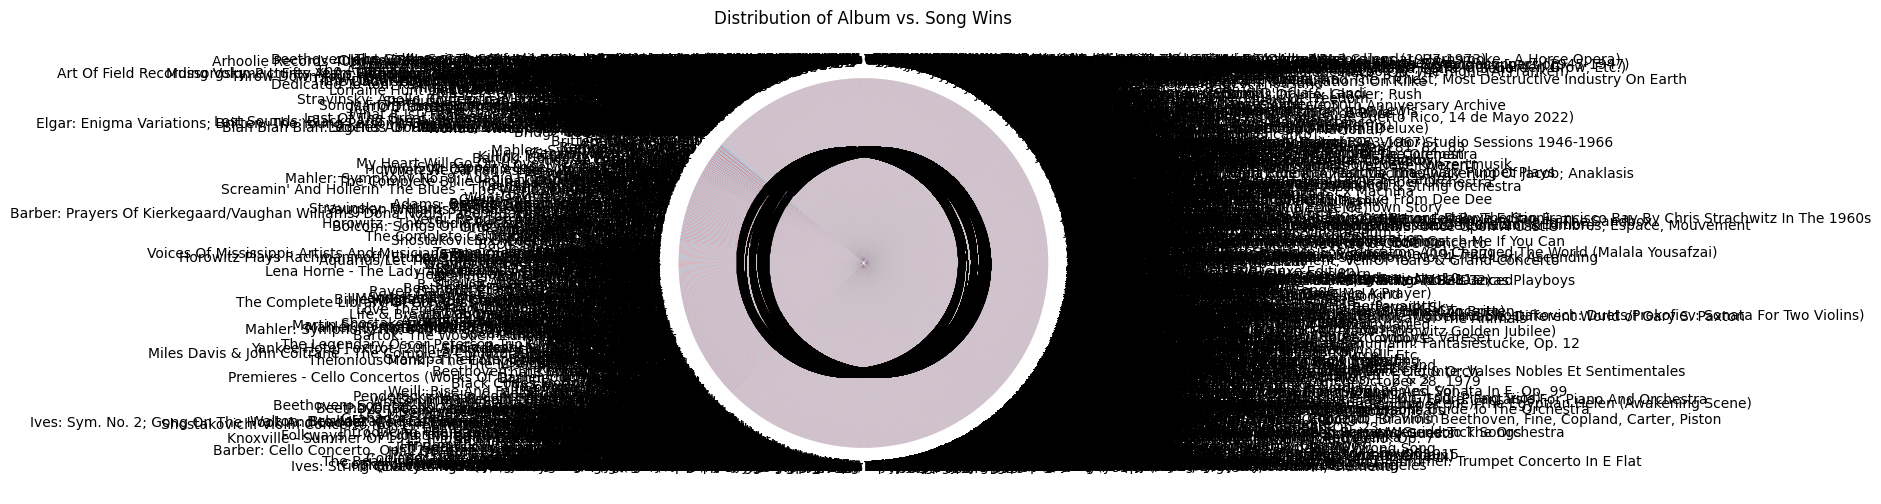

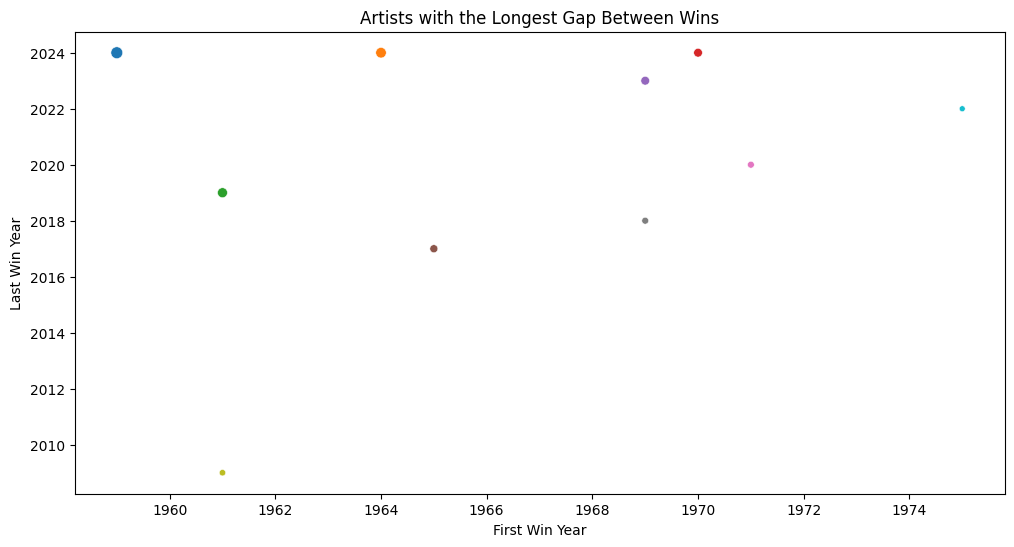

In [12]:
# Convert year to numeric if not already
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Filter only winners
df_winners = df[df['winner'] == True]

# 1. Number of Awards by Year
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='year', color='royalblue', alpha=0.8)
plt.xticks(rotation=45)
plt.title("Number of Grammy Awards Given Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Awards")
plt.show()

# 2. Most Awarded Categories
plt.figure(figsize=(12, 6))
categories = df_winners['category'].value_counts().head(10)
sns.barplot(x=categories.values, y=categories.index, palette='coolwarm')
plt.title("Top 10 Most Awarded Categories")
plt.xlabel("Number of Awards")
plt.ylabel("Category")
plt.show()

# 3. Top Grammy Award Winners
plt.figure(figsize=(12, 6))
top_winners = df_winners['artist'].value_counts().head(10)
sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')
plt.title("Top 10 Grammy Winners of All Time")
plt.xlabel("Number of Awards")
plt.ylabel("Artist")
plt.show()

# 4. Album vs. Song Wins Ratio
plt.figure(figsize=(6, 6))
labels = df_winners['song_or_album'].value_counts().index
sizes = df_winners['song_or_album'].value_counts().values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=140)
plt.title("Distribution of Album vs. Song Wins")
plt.show()

# 5. Artists with the Longest Gap Between Wins
df_winners['first_win'] = df_winners.groupby('artist')['year'].transform('min')
df_winners['last_win'] = df_winners.groupby('artist')['year'].transform('max')
df_winners['win_gap'] = df_winners['last_win'] - df_winners['first_win']
longest_gaps = df_winners[['artist', 'first_win', 'last_win', 'win_gap']].drop_duplicates().nlargest(10, 'win_gap')

plt.figure(figsize=(12, 6))
sns.scatterplot(x=longest_gaps['first_win'], y=longest_gaps['last_win'], size=longest_gaps['win_gap'], hue=longest_gaps['artist'], palette='tab10', legend=False)
plt.xlabel("First Win Year")
plt.ylabel("Last Win Year")
plt.title("Artists with the Longest Gap Between Wins")
plt.show()

## Predictive modeling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [14]:
# Convert year to numeric if not already
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [15]:
# Label Encoding for categorical columns
le = LabelEncoder()
categorical_cols = ['category', 'artist', 'song_or_album', 'url']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
# Define features and target
X = df[['year', 'annual_edition', 'category', 'artist', 'song_or_album']]
y = df['winner']

In [17]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [19]:
# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = accuracy
    print(f"{name}: {accuracy:.2f}%")

Logistic Regression: 85.97%
Random Forest: 96.39%
SVM: 86.34%
Decision Tree: 98.17%
KNN: 87.29%
Naive Bayes: 83.29%


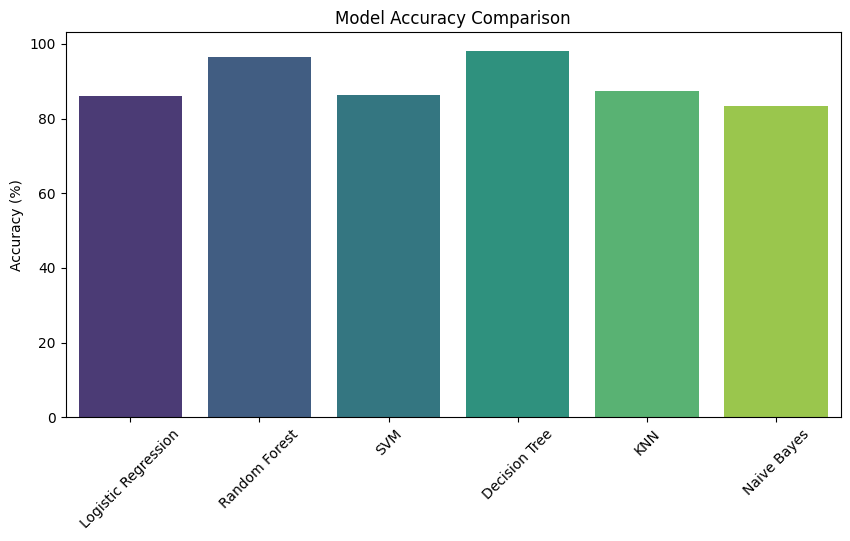

In [20]:
# Visualizing accuracy results
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.show()

## Thank you!!...pls upvote!!!!